# hw3: Обучение без учителя

*Спасибо ещё одному великому курсу mlcourse.ai и авторам: Ольга Дайховская (@aiho в Slack ODS), Юрий Кашницкий (@yorko в Slack ODS).*

# ВЫПОЛНИЛ БУГРЕНКОВ ВЛАДИМИР М8О-311Б-23

### О задании

В этом задании мы разберемся с тем, как работают методы снижения размерности и кластеризации данных. Заодно еще раз попрактикуемся в
задаче классификации.

Мы будем работать с набором данных [Samsung Human Activity Recognition](https://archive.ics.uci.edu/ml/datasets/Human+Activity+Recognition+Using+Smartphones). Данные поступают с акселерометров и гироскопов мобильных телефонов Samsung Galaxy S3 (подробнее про признаки – по ссылке на UCI выше), также известен вид активности человека с телефоном в кармане – ходил ли он, стоял, лежал, сидел или шел вверх/вниз по лестнице.

Вначале мы представим, что вид активности нам неизвестнен, и попробуем кластеризовать людей чисто на основе имеющихся признаков. Затем решим задачу определения вида физической активности именно как задачу классификации.

**Заполните код в клетках (где написано "Ваш код здесь") и ответьте на вопросы, выделив ответ полужирным** (``` **выделить двойными звёздочками** ```).

### Оценивание и штрафы
Вам необходимо ответить на 10 вопросов и выполнить 2 задания. Каждое из заданий и вопросов имеет определенную «стоимость» (указана в скобках). Максимально допустимая оценка за работу — 10 баллов. Неэффективная и/или неоригинальная реализация кода может негативно отразиться на оценке.

### Формат сдачи
Заполненный ноутбук ```hw3-unsupervised.ipynb``` необходимо загрузить на свой Github. Затем нужно оставить комментарий в Google-таблице с оценками в столбце "hw3" в строке со своей фамилией о том, что вы выполнили работу и оставить ссылку на ноутбук.


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm import tqdm_notebook

from matplotlib import pyplot as plt

plt.rcParams['figure.figsize'] = (12, 9)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.facecolor'] = '#2a2a2a'
plt.rcParams['axes.facecolor'] = '#333'
plt.rcParams['axes.edgecolor'] = 'white'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['text.color'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'
plt.rcParams['grid.color'] = 'gray'
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['legend.facecolor'] = '#333'
plt.rcParams['legend.edgecolor'] = 'white'

from sklearn import metrics
from sklearn.cluster import AgglomerativeClustering, KMeans, SpectralClustering
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

RANDOM_STATE = 17


In [4]:
X_train = np.loadtxt("UCI HAR Dataset/train/X_train.txt")
y_train = np.loadtxt("UCI HAR Dataset/train/y_train.txt").astype(int)

X_test = np.loadtxt("UCI HAR Dataset/test/X_test.txt")
y_test = np.loadtxt("UCI HAR Dataset/test/y_test.txt").astype(int)


In [5]:
# Проверим размерности
assert(X_train.shape == (7352, 561) and y_train.shape == (7352,))
assert(X_test.shape == (2947, 561) and y_test.shape == (2947,))

Для кластеризации нам не нужен вектор ответов, поэтому будем работать с объединением обучающей и тестовой выборок. Объедините *X_train* с *X_test*, а *y_train* – с *y_test*.

In [6]:
X = np.vstack([X_train, X_test])
y = np.concatenate([y_train, y_test])


Определим число уникальных значений меток целевого класса.

In [7]:
np.unique(y)

array([1, 2, 3, 4, 5, 6])

In [8]:
n_classes = np.unique(y).size

[Эти метки соответствуют:](https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.names)
- 1 - ходьбе
- 2 - подъему вверх по лестнице
- 3 - спуску по лестнице
- 4 - сидению
- 5 - стоянию
- 6 - лежанию

*уж простите, если звучание этих существительных кажется корявым :)*

Отмасштабируйте выборку с помощью `StandardScaler` с параметрами по умолчанию.

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Понижаем размерность с помощью PCA, оставляя столько компонент, сколько нужно для того, чтобы объяснить как минимум 90% дисперсии исходных (отмасштабированных) данных. Используйте отмасштабированную выборку и зафиксируйте random_state (константа RANDOM_STATE).

In [10]:
pca = PCA(n_components=0.9, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

**Вопрос 1:** (1 балл)

Какое минимальное число главных компонент нужно выделить, чтобы объяснить 90% дисперсии исходных (отмасштабированных) данных?

**Варианты:**
- 56
- 65  - ОТВЕТ
- 66
- 193

In [14]:
# Ваш код здесь
print(pca.n_components_)

65


**Вопрос 2:** (0.5 баллов)

Сколько процентов дисперсии приходится на первую главную компоненту? Округлите до целых процентов.

**Варианты:**
- 45
- 51 - ОТВЕТ
- 56
- 61

In [12]:
# Ваш код здесь
print(pca.explained_variance_ratio_[0] * 100)


50.7382210350133


Визуализируйте данные в проекции на первые две главные компоненты.

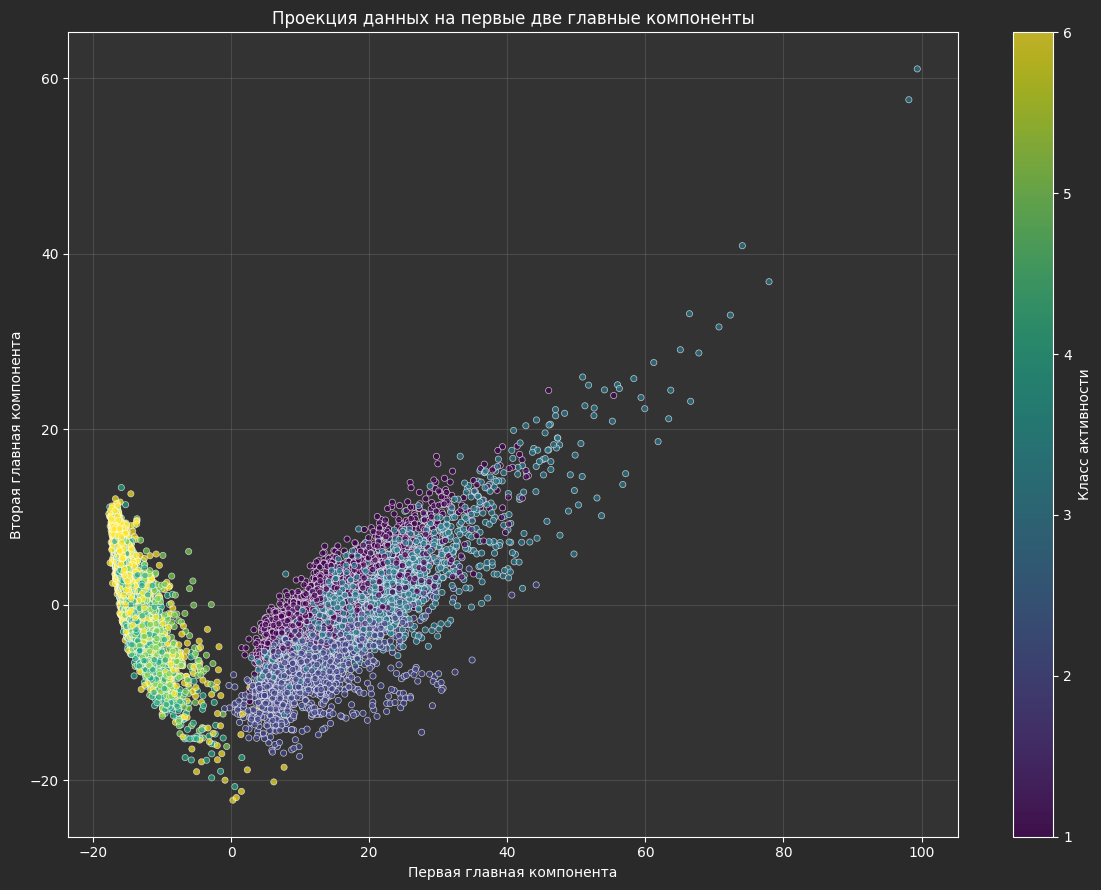

In [20]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, s=20, cmap='viridis', edgecolors='white', linewidth=0.5, alpha=0.7)
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.title('Проекция данных на первые две главные компоненты')
plt.colorbar(label='Класс активности')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Вопрос 3:** (0.5 баллов)

Если все получилось правильно, Вы увидите сколько-то кластеров, почти идеально отделенных друг от друга. Какие виды активности входят в эти кластеры?<br>

**Ответ:**
- 1 кластер: все 6 активностей
- **2 кластера: (ходьба, подъем вверх по лестнице, спуск по лестнице) и (сидение, стояние, лежание)**
- 3 кластера: (ходьба), (подъем вверх по лестнице, спуск по лестнице) и (сидение, стояние, лежание)
- 6 кластеров


ответ 2


------------------------------

**Задание 1.** (1 балл)

Сделайте кластеризацию данных методом `KMeans` (собственная имплементация и готовая реализация), обучив модель на данных со сниженной за счет PCA размерностью. В данном случае мы подскажем, что нужно искать именно 6 кластеров, но в общем случае мы не будем знать, сколько кластеров надо искать.

Параметры:

- **n_clusters** = n_classes (число уникальных меток целевого класса)
- **n_init** = 100
- **random_state** = RANDOM_STATE (для воспроизводимости результата)

Остальные параметры со значениями по умолчанию.

In [23]:
kmeans = KMeans(n_clusters=n_classes, n_init=100, random_state=RANDOM_STATE)
cluster_labels = kmeans.fit_predict(X_pca)
print(f"колво кластеров: {n_classes}")
print(f"сумма квадратов расстояний до ближайших центроидов: {kmeans.inertia_}")
print(f"колво итераций до сходимости: {kmeans.n_iter_}")

колво кластеров: 6
сумма квадратов расстояний до ближайших центроидов: 2003454.8999158172
колво итераций до сходимости: 26


Визуализируйте данные в проекции на первые две главные компоненты. Раскрасьте точки в соответствии с полученными метками кластеров.

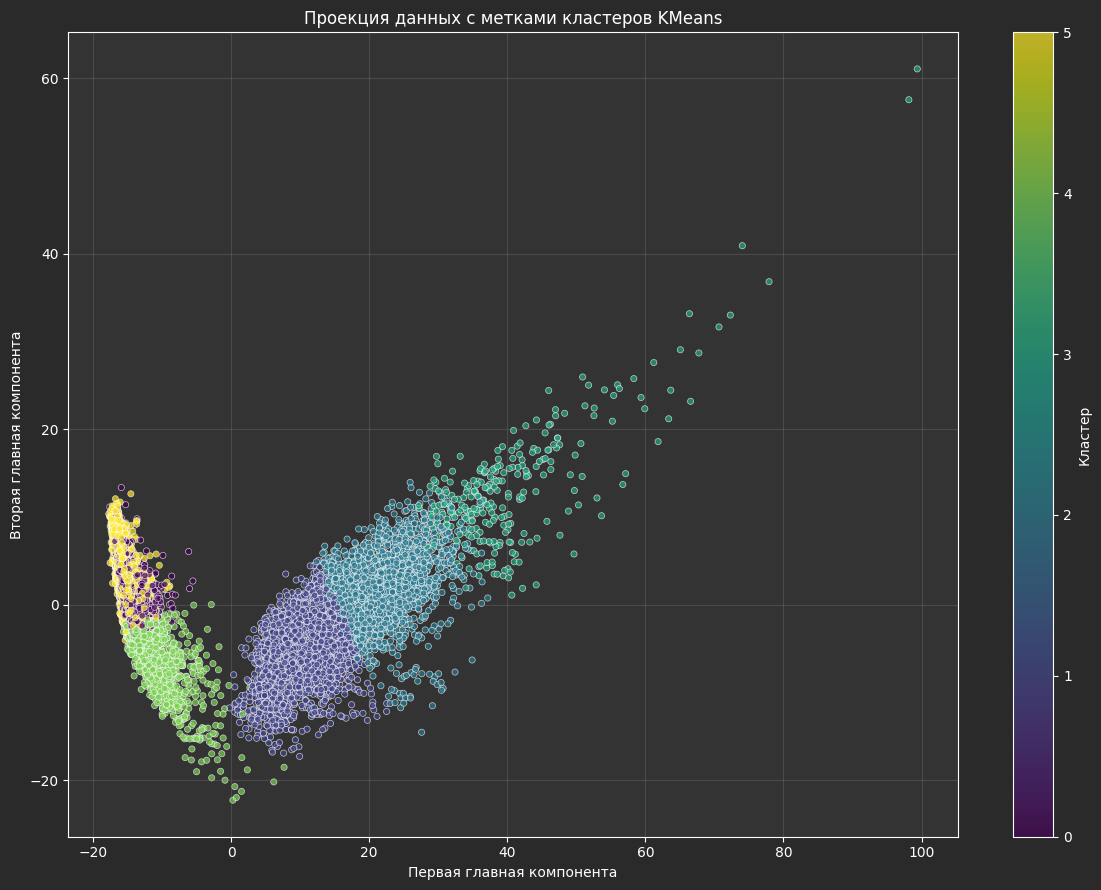

In [25]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, s=20, cmap='viridis', edgecolors='white', linewidth=0.5, alpha=0.7)
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.title('Проекция данных с метками кластеров KMeans')
plt.colorbar(label='Кластер')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Посмотрите на соответствие между метками кластеров и исходными метками классов и на то, какие виды активностей алгоритм `KMeans` путает.

In [ ]:
tab = pd.crosstab(y, cluster_labels, margins=True)
tab.index = ['ходьба', 'подъем вверх по лестнице',
             'спуск по лестнице', 'сидение', 'стояние', 'лежание', 'все']
tab.columns = ['cluster' + str(i + 1) for i in range(6)] + ['все']
tab

max_cluster_fractions = []
activities = ['ходьба', 'подъем вверх по лестнице', 'спуск по лестнице', 'сидение', 'стояние', 'лежание']

for i in range(6):
    class_total = tab.iloc[i, -1]
    max_in_cluster = tab.iloc[i, :-1].max()
    fraction = max_in_cluster / class_total
    max_cluster_fractions.append(fraction)
    print(f"{activities[i]}: {max_in_cluster}/{class_total} = {fraction:.4f}")

print(f"\nЛучше всего отделилась активность: {activities[np.argmax(max_cluster_fractions)]}")
print(f"Максимальная доля: {max(max_cluster_fractions):.4f}")



ходьба: 903/1722 = 0.5244
подъем вверх по лестнице: 1241/1544 = 0.8038
спуск по лестнице: 890/1406 = 0.6330
сидение: 1235/1777 = 0.6950
стояние: 1344/1906 = 0.7051
лежание: 1558/1944 = 0.8014

Лучше всего отделилась активность: подъем вверх по лестнице
Максимальная доля: 0.8038


Видим, что каждому классу (т.е. каждой активности) соответствуют несколько кластеров. Давайте посмотрим на максимальную долю объектов в классе, отнесенных к какому-то одному кластеру. Это будет простой метрикой, характеризующей, насколько легко класс отделяется от других при кластеризации.

Пример: если для класса "спуск по лестнице", в котором 1406 объектов,  распределение кластеров такое:
 - кластер 1 – 900
 - кластер 3 – 500
 - кластер 6 – 6,

то такая доля будет 900 / 1406 $\approx$ 0.64.


**Вопрос 4:** (1 балл)

Какой вид активности отделился от остальных лучше всего в терминах простой  метрики, описанной выше?<br>

**Ответ:**
- ходьба
- стояние
- спуск по лестнице
- перечисленные варианты не подходят - ПРАВИЛЬНЫЙ ОТВЕТ

Видно, что kMeans не очень хорошо отличает только активности друг от друга. Используйте метод локтя, чтобы выбрать оптимальное количество кластеров. Параметры алгоритма и данные используем те же, что раньше, меняем только `n_clusters`.

In [28]:
# Метод локтя для определения оптимального числа кластеров
inertia = []
for k in tqdm_notebook(range(1, n_classes + 1)):
    kmeans_temp = KMeans(n_clusters=k, n_init=100, random_state=RANDOM_STATE)
    kmeans_temp.fit(X_pca)
    inertia.append(kmeans_temp.inertia_)


/var/folders/r9/g956bfqx28z8dpycm0ztg6n40000gn/T/ipykernel_64192/675883138.py:3: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for k in tqdm_notebook(range(1, n_classes + 1)):


  0%|          | 0/6 [00:00<?, ?it/s]

**Вопрос 5:** (1 балл)

Какое количество кластеров оптимально выбрать, согласно методу локтя?<br>

**Ответ:**
- 1
- 2 - ОТВЕТ
- 3
- 4

------------------------

Попробуем еще один метод кластеризации, который описывался в статье – агломеративную кластеризацию.

In [30]:
ag = AgglomerativeClustering(n_clusters=n_classes,
                             linkage='ward').fit(X_pca)

Посчитайте Adjusted Rand Index (`sklearn.metrics`) для получившегося разбиения на кластеры и для `KMeans` с параметрами из задания к 4 вопросу.

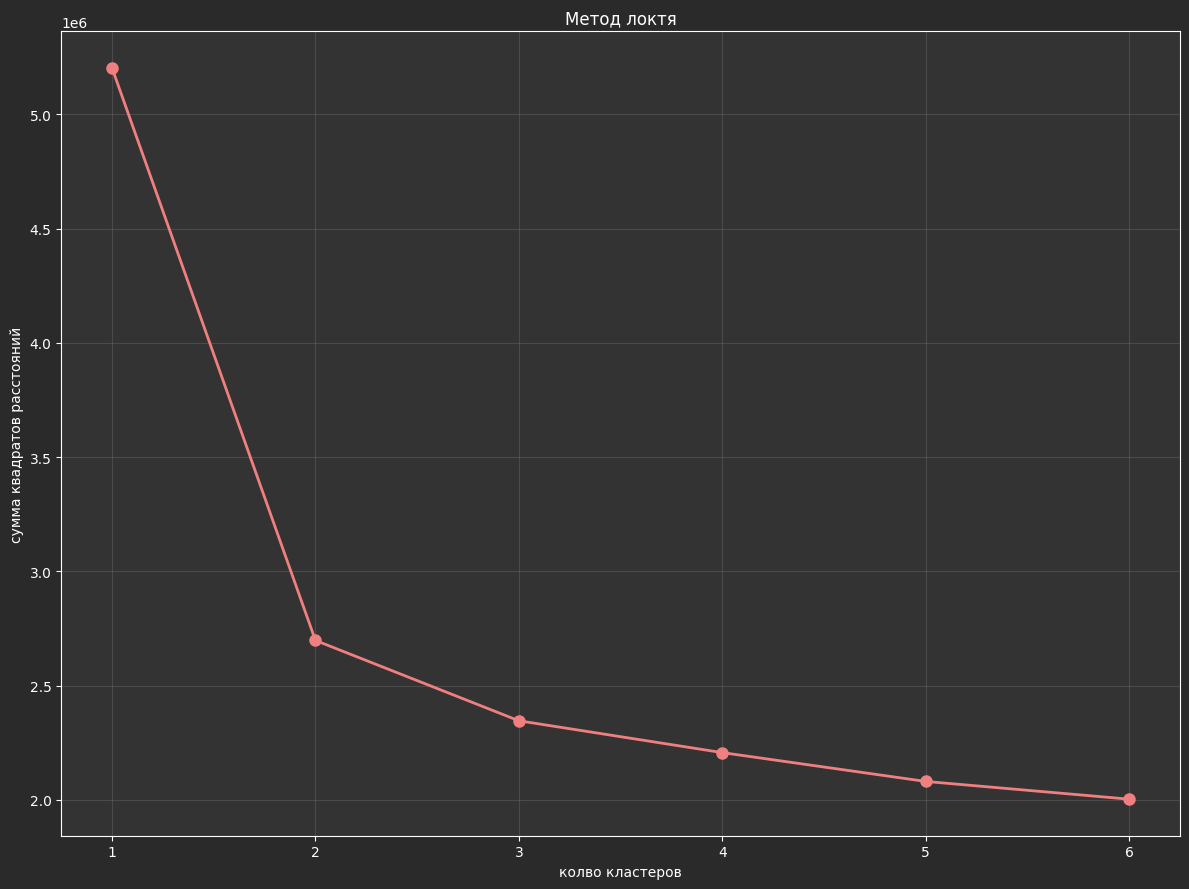

значение инерции:
k=1: 5202757.68
k=2: 2697926.76
k=3: 2346425.10
k=4: 2207131.82
k=5: 2080985.11
k=6: 2003454.90
ari_kmeans: 0.4198070012602345
аri_agglomerative: 0.49362763373004886


In [33]:
plt.plot(range(1, n_classes + 1), inertia, marker='o', linewidth=2, markersize=8, color='lightcoral')
plt.xlabel('колво кластеров')
plt.ylabel('сумма квадратов расстояний')
plt.title('Метод локтя')
plt.xticks(range(1, n_classes + 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("значение инерции:")
for k, iner in enumerate(inertia, 1):
    print(f"k={k}: {iner:.2f}")


ag = AgglomerativeClustering(n_clusters=n_classes, linkage='ward').fit(X_pca)
ari_kmeans = metrics.adjusted_rand_score(y, cluster_labels)
ari_agglomerative = metrics.adjusted_rand_score(y, ag.labels_)

print(f"ari_kmeans: {ari_kmeans}")
print(f"аri_agglomerative: {ari_agglomerative}")



**Вопрос 6:** (1 балл)

Отметьте все верные утверждения.<br>

**Варианты:**
- Согласно ARI, KMeans справился с кластеризацией хуже, чем Agglomerative Clustering
- Для ARI не имеет значения какие именно метки присвоены кластерам, имеет значение только разбиение объектов на кластеры
- В случае случайного разбиения на кластеры ARI будет близок к нулю

все варианты верные

-------------------------------

Можно заметить, что задача не очень хорошо решается именно как задача кластеризации, если выделять несколько кластеров (> 2). Давайте теперь решим задачу классификации, вспомнив, что данные у нас размечены.  

Для классификации используйте метод опорных векторов – класс `sklearn.svm.LinearSVC`. Мы в курсе отдельно не рассматривали этот алгоритм, но он очень известен, почитать про него можно, например, в материалах Евгения Соколова –  [тут](https://github.com/esokolov/ml-course-msu/blob/master/ML16/lecture-notes/Sem11_linear.pdf).

Настройте для `LinearSVC` гиперпараметр `C` с помощью `GridSearchCV`.

- Обучите новый `StandardScaler` на обучающей выборке (со всеми исходными признаками), прмиените масштабирование к тестовой выборке
- В `GridSearchCV` укажите  cv=3.

In [34]:
scaler_svc = StandardScaler()
X_train_scaled = scaler_svc.fit_transform(X_train)
X_test_scaled = scaler_svc.transform(X_test)

In [35]:
svc = LinearSVC(random_state=RANDOM_STATE)
svc_params = {'C': [0.001, 0.01, 0.1, 1, 10]}

In [36]:
grid_search = GridSearchCV(svc, svc_params, cv=3, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

best_svc = grid_search.best_estimator_

print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Лучший score (CV): {grid_search.best_score_:.4f}")
print(f"Accuracy на тестовой выборке: {best_svc.score(X_test_scaled, y_test):.4f}")

/Users/vladimirbugrenkov/education/ml/ml-hw-labs/.venv311/lib/python3.11/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/vladimirbugrenkov/education/ml/ml-hw-labs/.venv311/lib/python3.11/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/vladimirbugrenkov/education/ml/ml-hw-labs/.venv311/lib/python3.11/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Лучшие параметры: {'C': 0.1}
Лучший score (CV): 0.9380
Accuracy на тестовой выборке: 0.9620


**Вопрос 7** (0.5 баллов)

Какое значение гиперпараметра `C` было выбрано лучшим по итогам кросс-валидации?<br>

**Ответ:**
- 0.001
- 0.01
- 0.1 - ОТВЕТ
- 1
- 10

In [37]:
y_predicted = best_svc.predict(X_test_scaled)

In [38]:
tab = pd.crosstab(y_test, y_predicted, margins=True)
tab.index = ['ходьба', 'подъем вверх по лестнице', 'спуск по лестнице',
             'сидение', 'стояние', 'лежание', 'все']
tab.columns = tab.index
tab

,ходьба,подъем вверх по лестнице,спуск по лестнице,сидение,стояние,лежание,все
ходьба,494,2,0,0,0,0,496
подъем вверх по лестнице,12,459,0,0,0,0,471
спуск по лестнице,2,4,413,1,0,0,420
сидение,0,4,0,426,61,0,491
стояние,0,0,0,15,517,0,532
лежание,0,0,0,0,11,526,537
все,508,469,413,442,589,526,2947


**Вопрос 8:** (0.5 балл)

Какой вид активности SVM определяет хуже всего в терминах точности? Полноты? <br>

**варианты:**
- по точности – подъем вверх по лестнице, по полноте – лежание
- по точности – лежание, по полноте – сидение
- по точности – ходьба, по полноте – ходьба
- по точности – сидение, по полноте – стояние

Ответ: - по точности – сидение, по полноте – стояние 

In [39]:
from sklearn.metrics import classification_report as cr
print(cr(y_test, y_predicted, 
         target_names=['ходьба', 'подъем вверх', 'спуск', 'сидение', 'стояние', 'лежание']))
acts = ['ходьба', 'подъем вверх', 'спуск', 'сидение', 'стояние', 'лежание']
print("\nТочность и полнота по классам:")
print('\n'.join(f"{acts[i]}: Precision={tab.iloc[i,i]/tab.iloc[-1,i]:.4f}, Recall={tab.iloc[i,i]/tab.iloc[i,-1]:.4f}" 
                for i in range(6)))


              precision    recall  f1-score   support

      ходьба       0.97      1.00      0.98       496
подъем вверх       0.98      0.97      0.98       471
       спуск       1.00      0.98      0.99       420
     сидение       0.96      0.87      0.91       491
     стояние       0.88      0.97      0.92       532
     лежание       1.00      0.98      0.99       537

    accuracy                           0.96      2947
   macro avg       0.97      0.96      0.96      2947
weighted avg       0.96      0.96      0.96      2947


Точность и полнота по классам:
ходьба: Precision=0.9724, Recall=0.9960
подъем вверх: Precision=0.9787, Recall=0.9745
спуск: Precision=1.0000, Recall=0.9833
сидение: Precision=0.9638, Recall=0.8676
стояние: Precision=0.8778, Recall=0.9718
лежание: Precision=1.0000, Recall=0.9795


Наконец, проделайте то же самое, что в 7 вопросе, только добавив PCA.

- Используйте выборки `X_train_scaled` и `X_test_scaled`
- Обучите тот же PCA, что раньше, на отмасшабированной обучающей выборке, примените преобразование к тестовой
- Настройте гиперпараметр `C` на кросс-валидации по обучающей выборке с PCA-преобразованием. Вы заметите, насколько это проходит быстрее, чем раньше.

**Вопрос 9:** (1 балл)

Какова разность между лучшим качеством (долей верных ответов) на кросс-валидации в случае всех 561 исходных признаков и во втором случае, когда применялся метод главных компонент? Округлите до целых процентов.<br>

**Варианты:**
- Качество одинаковое
- 2%
- 4% - ОТВЕТ
- 10%
- 20%


In [43]:
pca = PCA(n_components=0.9, random_state=RANDOM_STATE)
X_tr_pca, X_te_pca = pca.fit_transform(X_train_scaled), pca.transform(X_test_scaled)
print(f"Компонент: {pca.n_components_}, Дисперсия: {pca.explained_variance_ratio_.sum():.4f}")

gs_pca = GridSearchCV(LinearSVC(random_state=RANDOM_STATE), {'C': [0.001, 0.01, 0.1, 1, 10]}, cv=3, n_jobs=-1)
gs_pca.fit(X_tr_pca, y_train)
print(f"\nПараметры: {gs_pca.best_params_}, CV: {gs_pca.best_score_:.4f}, Test: {gs_pca.score(X_te_pca, y_test):.4f}")

cv_f, cv_p = grid_search.best_score_, gs_pca.best_score_
print(f"\nБез PCA: {cv_f:.4f} ({cv_f*100:.2f}%), С PCA: {cv_p:.4f} ({cv_p*100:.2f}%), дельта: {abs(cv_f-cv_p)*100:.2f}% ({round(abs(cv_f-cv_p)*100)}%)")


Компонент: 63, Дисперсия: 0.9005

Параметры: {'C': 0.1}, CV: 0.8984, Test: 0.9192

Без PCA: 0.9380 (93.80%), С PCA: 0.8984 (89.84%), дельта: 3.96% (4%)


**Вопрос 10:** (1 балл)

Выберите все верные утверждения:

**Варианты:**
- Метод главных компонент в данном случае позволил уменьшить время обучения модели, при этом качество (доля верных ответов на кросс-валидации) очень пострадало, более чем на 10%
- PCA можно использовать для визуализации данных, однако для этой задачи есть и лучше подходящие методы, например, tSNE. Зато PCA имеет меньшую вычислительную сложность
- PCA строит линейные комбинации исходных признаков, и в некоторых задачах они могут плохо интерпретироваться человеком


ответ: 2,3 

In [47]:
print("Проверка утверждения 1:")
print(f"Потеря качества с PCA: {difference:.2f}%")
print(f"Больше 10%? {difference > 10}")
print()

import time
print("Проверка времени обучения:")

# Без PCA
start = time.time()
svc_time = LinearSVC(C=0.1, random_state=RANDOM_STATE)
svc_time.fit(X_train_scaled, y_train)
time_full = time.time() - start

# С PCA
start = time.time()
svc_pca_time = LinearSVC(C=0.1, random_state=RANDOM_STATE)
svc_pca_time.fit(X_train_pca, y_train)
time_pca = time.time() - start

print(f"Время без PCA : {time_full:.4f} сек")
print(f"Время с PCA: {time_pca:.4f} сек")
print(f"Ускорение: {time_full/time_pca:.2f}x")
print()

print("Первая главная компонента:")
print(pca_svc.components_[0][:10])


Проверка утверждения 1:
Потеря качества с PCA: 3.96%
Больше 10%? False

Проверка времени обучения:
Время без PCA : 2.5987 сек
Время с PCA: 0.1474 сек
Ускорение: 17.64x

Первая главная компонента:
[ 2.80886217e-05 -2.47348433e-03 -1.52730914e-03  5.62131467e-02
  5.67880728e-02  5.43626669e-02  5.59690425e-02  5.62637609e-02
  5.38864311e-02  5.58922043e-02]


**Задание 2.** (1 балл)

Попробуйте использовать DBSCAN в качестве алгоритма кластеризации и метод понижения размерности tSNE.

Размерность данных после t-SNE: (10299, 2)



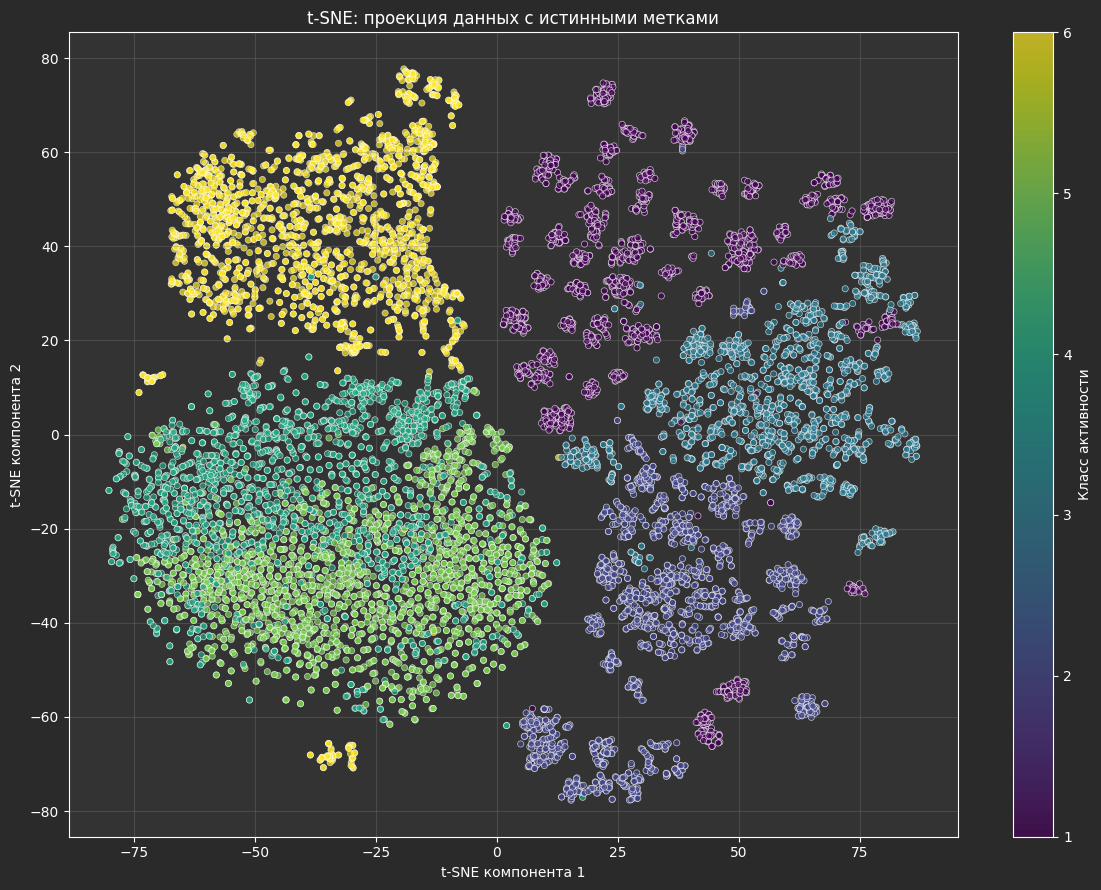

Запускаем DBSCAN на t-SNE-признаках...
Найдено кластеров (без учёта шума): 54
Количество объектов, отнесённых к шуму: 121
Метки кластеров, которые нашёл DBSCAN: [-1  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22
 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46
 47 48 49 50 51 52 53]



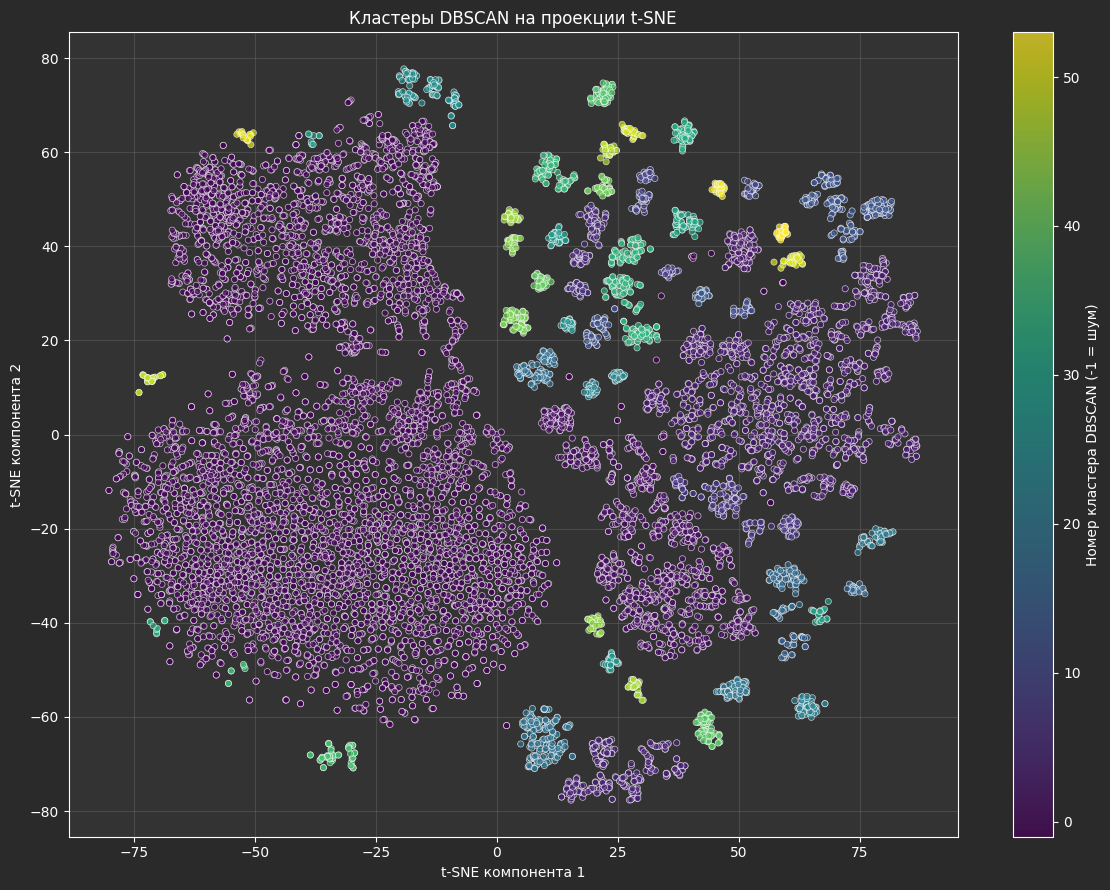

Adjusted Rand Index для DBSCAN относительно истинных меток: 0.3369


In [ ]:
from sklearn.manifold import TSNE
from sklearn.cluster import DBSCAN

tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

print(f"Размерность данных после t-SNE: {X_tsne.shape}")
print()

plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, s=20, cmap='viridis',
            edgecolors='white', linewidth=0.5, alpha=0.7)
plt.xlabel('t-SNE компонента 1')
plt.ylabel('t-SNE компонента 2')
plt.title('t-SNE: проекция данных с истинными метками')
plt.colorbar(label='Класс активности')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


dbscan = DBSCAN(eps=3, min_samples=10)
dbscan_labels = dbscan.fit_predict(X_tsne)

n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"Найдено кластеров: {n_clusters_dbscan}")
print(f"Количество объектов, отнесённых к шуму: {n_noise}")
print(f"Метки кластеров, которые нашёл DBSCAN: {np.unique(dbscan_labels)}")
print()

plt.figure(figsize=(12, 9))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=dbscan_labels, s=20, cmap='viridis',
            edgecolors='white', linewidth=0.5, alpha=0.7)
plt.xlabel('t-SNE компонента 1')
plt.ylabel('t-SNE компонента 2')
plt.title('Кластеры DBSCAN на проекции t-SNE')
plt.colorbar(label='Номер кластера DBSCAN (-1 = шум)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

ari_dbscan = metrics.adjusted_rand_score(y, dbscan_labels)
print(f"Adjusted Rand Index для DBSCAN относительно истинных меток: {ari_dbscan:.4f}")
